In [511]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [512]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\further_cleaned_dataset.csv")
df.head(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Age,Miles_per_year,Brand_Model
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,1,Hybrid,3.5,186005,6,Automatic,4x4,4,Left wheel,Silver,12,15,12400.333333,LEXUS_RX 450
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,6,Tiptronic,4x4,4,Left wheel,Black,8,14,13714.285714,CHEVROLET_Equinox
2,8467,NaN,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,4,Variator,Front,4,Right-hand drive,Black,2,19,10526.315789,HONDA_FIT
3,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,4,Automatic,4x4,4,Left wheel,White,0,14,12069.000000,FORD_Escape
4,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,4,Automatic,Front,4,Left wheel,Silver,4,11,8354.636364,HONDA_FIT
5,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,1,Diesel,2.0,160931,4,Automatic,Front,4,Left wheel,White,4,9,17881.222222,HYUNDAI_Santa FE
6,1803,761.0,TOYOTA,Prius,2010,Hatchback,1,Hybrid,1.8,258909,4,Automatic,Front,4,Left wheel,White,12,15,17260.600000,TOYOTA_Prius
7,549,751.0,HYUNDAI,Sonata,2013,Sedan,1,Petrol,2.4,216118,4,Automatic,Front,4,Left wheel,Grey,12,12,18009.833333,HYUNDAI_Sonata
8,1098,394.0,TOYOTA,Camry,2014,Sedan,1,Hybrid,2.5,398069,4,Automatic,Front,4,Left wheel,Black,12,11,36188.090909,TOYOTA_Camry
9,26657,NaN,LEXUS,RX 350,2007,Jeep,1,Petrol,3.5,128500,6,Automatic,4x4,4,Left wheel,Silver,12,18,7138.888889,LEXUS_RX 350


In [513]:
# 数据预处理函数
def preprocess_data(df):
    # 处理缺失值
    df['Levy'] = df['Levy'].fillna(df['Levy'].median())
    
    # 对数变换长尾分布特征
    df['Mileage_log'] = np.log1p(df['Mileage'])
    df['Engine_vol_log'] = np.log1p(df['Engine volume'])
    df = df[df['Price'] < 1e6]
    # 时间敏感特征
    df['Depreciation'] = (2024 - df['Prod. year']) * df['Mileage'] / 1e5
    # 品牌溢价编码
    brand_prestige = {'LEXUS': 5, 'MERCEDES-BENZ': 4, 'BMW': 4, 'TOYOTA': 3}
    df['Brand_Score'] = df['Manufacturer'].map(brand_prestige).fillna(2)
    
    return df

In [514]:
df = preprocess_data(df)

In [515]:
# 定义特征和目标变量
X = df.drop(['Price', 'Mileage', 'Engine volume'], axis=1)  # 移除原始数值特征
y = np.log1p(df['Price'])  # 对数变换目标变量

In [516]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [517]:
# 特征预处理管道
numeric_features = ['Levy', 'Prod. year', 'Cylinders', 'Airbags', 'Age', 'Miles_per_year']
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])
categorical_features = ['Manufacturer', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels']
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=50))
])

In [ ]:
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.layers import LeakyReLU, PReLU
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.layers import Input, Add

# 构建MLP模型
# def build_mlp(input_dim):
#     init = HeNormal(seed=42)
#     reg = l1_l2(l1=1e-5, l2=1e-4)
    
#     # 使用函数式API构建残差连接
#     input_tensor = Input(shape=(input_dim,))
    
#     # 输入分支
#     x = Dense(512, kernel_initializer=init, kernel_regularizer=reg)(input_tensor)
#     x = BatchNormalization()(x)
#     x = LeakyReLU(alpha=0.1)(x)
#     x = Dropout(0.3)(x)
    
#     # 残差块
#     residual = x
#     x = Dense(256, kernel_regularizer=reg)(x)
#     x = BatchNormalization()(x)
#     x = PReLU()(x)
#     x = Dropout(0.2)(x)
#     x = Dense(512)(x)
#     x = Add()([residual, x])  # 正确使用Add层
    
#     # 后续层保持原样
#     x = Dense(64, activation='selu', kernel_initializer='lecun_normal')(x)
#     outputs = Dense(1, activation='linear')(x)
    
#     model = tf.keras.Model(inputs=input_tensor, outputs=outputs)
    
#     # 混合损失函数
#     def hybrid_loss(y_true, y_pred):
#         mae = tf.keras.losses.MAE(y_true, y_pred)
#         mse = tf.keras.losses.MSE(y_true, y_pred)
#         return 0.7*mae + 0.3*mse
    
#     # 自定义R²指标
#     class R2Score(tf.keras.metrics.Metric):
#         def __init__(self, name='r2', **kwargs):
#             super().__init__(name=name, **kwargs)
#             self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
#             self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')

#         def update_state(self, y_true, y_pred, sample_weight=None):
#             y_true = tf.cast(y_true, tf.float32)
#             y_pred = tf.cast(y_pred, tf.float32)
#             ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
#             ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
#             self.ss_res.assign_add(ss_res)
#             self.ss_tot.assign_add(ss_tot)

#         def result(self):
#             return 1 - self.ss_res / (self.ss_tot + tf.keras.backend.epsilon())

#     # 模型编译
#     model.compile(
#         optimizer=Nadam(learning_rate=0.001, clipvalue=0.5),
#         loss=hybrid_loss,
#         metrics=[R2Score(), 'mae']
#     )
    
#     return model

def build_mlp(input_dim):
    init = tf.keras.initializers.HeNormal(seed=42)
    reg = tf.keras.regularizers.l1_l2(l1=1e-5, l2=1e-4)
    
    # 输入层
    input_tensor = tf.keras.layers.Input(shape=(input_dim,))
    
    # 初始特征提取
    x = tf.keras.layers.Dense(512, kernel_initializer=init, kernel_regularizer=reg)(input_tensor)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # 残差块
    residual = x
    x = tf.keras.layers.Dense(256, kernel_regularizer=reg)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.PReLU()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512)(x)
    x = tf.keras.layers.Add()([residual, x])
    
    # 特征注意力机制
    def feature_attention(inputs):
        """ 结构化数据特征注意力 """
        # 生成注意力分数 [batch_size, features]
        attn_scores = tf.keras.layers.Dense(
            inputs.shape[-1],  # 保持与特征维度一致
            activation='sigmoid',  # 使用sigmoid替代softmax允许特征多激活
            kernel_initializer='glorot_normal'
        )(inputs)
        
        # 应用注意力加权 [batch_size, features]
        weighted_features = tf.keras.layers.Multiply()([inputs, attn_scores])
        
        # 残差连接
        return tf.keras.layers.Add()([inputs, weighted_features])
    
    x = feature_attention(x)

    # 混合损失函数
    def hybrid_loss(y_true, y_pred):
        mae = tf.keras.losses.MAE(y_true, y_pred)
        mse = tf.keras.losses.MSE(y_true, y_pred)
        return 0.7*mae + 0.3*mse
    
    # 后续处理
    x = tf.keras.layers.Dense(64, activation='selu', kernel_initializer='lecun_normal')(x)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)
    
    # 构建模型
    model = tf.keras.Model(inputs=input_tensor, outputs=outputs)

    # 自定义R²指标
    class R2Score(tf.keras.metrics.Metric):
        def __init__(self, name='r2', **kwargs):
            super().__init__(name=name, **kwargs)
            self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
            self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')

        def update_state(self, y_true, y_pred, sample_weight=None):
            y_true = tf.cast(y_true, tf.float32)
            y_pred = tf.cast(y_pred, tf.float32)
            ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
            ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
            self.ss_res.assign_add(ss_res)
            self.ss_tot.assign_add(ss_tot)

        def result(self):
            return 1 - self.ss_res / (self.ss_tot + tf.keras.backend.epsilon())
    
    # 编译配置（保持原有损失函数和指标）
    model.compile(
        optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001, clipvalue=0.5),
        loss=hybrid_loss,
        metrics=[R2Score(), 'mae']
    )
    
    return model

In [519]:
# 数据预处理
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=50), categorical_features)
])

In [520]:
# 数据预处理
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [521]:
# 获取预处理后的特征维度
input_dim = X_train_processed.shape[1]

In [522]:
# 初始化模型
mlp = build_mlp(input_dim)

c:\Users\wjw20\miniconda3\envs\IS6400\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


NameError: name 'hybrid_loss' is not defined

In [ ]:
# 添加学习率调度函数（在调用 fit() 之前）
def lr_schedule(epoch):
    """ 动态调整学习率 """
    base_lr = 0.001
    decay_rate = 0.9
    return base_lr * (decay_rate ** (epoch // 10))  # 每10个epoch衰减一次

In [ ]:
# 训练模型
history = mlp.fit(
    X_train_processed.astype('float32'), 
    y_train.values.astype('float32'),
    validation_split=0.15,
    epochs=100,
    batch_size=128,
    callbacks=[
        LearningRateScheduler(lr_schedule),
        tf.keras.callbacks.TensorBoard(log_dir='./logs'),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
    ],
)

Epoch 1/100
68/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6035 - mae: 2.0610 - r2: -514.7456

78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.2957 - mae: 1.9620 - r2: -480.0361 - val_loss: 5.3016 - val_mae: 2.9600 - val_r2: -514.2868 - learning_rate: 0.0010
Epoch 2/100
69/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5047 - mae: 0.9800 - r2: -182.6463

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5034 - mae: 0.9790 - r2: -182.8632 - val_loss: 2.4558 - val_mae: 1.6601 - val_r2: -253.4370 - learning_rate: 0.0010
Epoch 3/100
72/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4045 - mae: 0.9175 - r2: -181.6102

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4050 - mae: 0.9173 - r2: -181.7187 - val_loss: 1.8174 - val_mae: 1.2453 - val_r2: -217.4535 - learning_rate: 0.0010
Epoch 4/100
74/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3766 - mae: 0.8878 - r2: -183.3992

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3766 - mae: 0.8877 - r2: -183.4248 - val_loss: 1.4667 - val_mae: 0.9691 - val_r2: -202.9014 - learning_rate: 0.0010
Epoch 5/100
69/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3486 - mae: 0.8763 - r2: -186.9842

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9378 - mae: 0.6491 - r2: -200.7205 - val_loss: 1.0542 - val_mae: 0.7014 - val_r2: -193.4868 - learning_rate: 4.7830e-04
Epoch 78/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9443 - mae: 0.6552 - r2: -199.7641 - val_loss: 1.0666 - val_mae: 0.7107 - val_r2: -193.7103 - learning_rate: 4.7830e-04
Epoch 79/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9104 - mae: 0.6325 - r2: -198.9338 - val_loss: 1.0552 - val_mae: 0.7047 - val_r2: -195.1418 - learning_rate: 4.7830e-04
Epoch 80/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8948 - mae: 0.6291 - r2: -202.2790 - val_loss: 1.0616 - val_mae: 0.7204 - val_r2: -191.4467 - learning_rate: 4.7830e-04
Epoch 81/100
71/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8939 - mae: 0.6254 - r2: -201.4193

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8965 - mae: 0.6268 - r2: -201.3663 - val_loss: 1.0508 - val_mae: 0.7052 - val_r2: -195.3303 - learning_rate: 4.3047e-04
Epoch 82/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9269 - mae: 0.6418 - r2: -199.5987 - val_loss: 1.0571 - val_mae: 0.7082 - val_r2: -196.6901 - learning_rate: 4.3047e-04
Epoch 83/100
72/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9081 - mae: 0.6364 - r2: -202.7249

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9094 - mae: 0.6369 - r2: -202.5558 - val_loss: 1.0456 - val_mae: 0.7005 - val_r2: -197.9206 - learning_rate: 4.3047e-04
Epoch 84/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9105 - mae: 0.6360 - r2: -201.6960 - val_loss: 1.0558 - val_mae: 0.7048 - val_r2: -199.3328 - learning_rate: 4.3047e-04
Epoch 85/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9085 - mae: 0.6386 - r2: -202.1643 - val_loss: 1.0606 - val_mae: 0.7112 - val_r2: -200.6305 - learning_rate: 4.3047e-04
Epoch 86/100
74/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9129 - mae: 0.6352 - r2: -202.6107

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9135 - mae: 0.6356 - r2: -202.5275 - val_loss: 1.0414 - val_mae: 0.6947 - val_r2: -192.7073 - learning_rate: 4.3047e-04
Epoch 87/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9095 - mae: 0.6349 - r2: -200.7413 - val_loss: 1.0722 - val_mae: 0.7264 - val_r2: -197.4813 - learning_rate: 4.3047e-04
Epoch 88/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9080 - mae: 0.6383 - r2: -203.4673 - val_loss: 1.0468 - val_mae: 0.7037 - val_r2: -199.2433 - learning_rate: 4.3047e-04
Epoch 89/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8915 - mae: 0.6302 - r2: -202.1824 - val_loss: 1.0534 - val_mae: 0.7044 - val_r2: -192.9456 - learning_rate: 4.3047e-04
Epoch 90/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9410 - mae: 0.6538 - r2: -198.6781 - val_loss: 1.0455 - val_mae: 0.7019 - val_r2: -198.1090 - learning_rate: 4.3047e-04
Epoch 91/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8944 - mae: 0.6250 - r2: -201.3449 - val

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9163 - mae: 0.6374 - r2: -200.4815 - val_loss: 1.0366 - val_mae: 0.6883 - val_r2: -199.5881 - learning_rate: 3.8742e-04
Epoch 98/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8938 - mae: 0.6276 - r2: -203.0488 - val_loss: 1.0431 - val_mae: 0.7010 - val_r2: -196.4630 - learning_rate: 3.8742e-04
Epoch 99/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9066 - mae: 0.6408 - r2: -201.1050 - val_loss: 1.0430 - val_mae: 0.6950 - val_r2: -200.6969 - learning_rate: 3.8742e-04
Epoch 100/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8893 - mae: 0.6292 - r2: -202.9538 - val_loss: 1.0443 - val_mae: 0.7000 - val_r2: -198.6225 - learning_rate: 3.8742e-04


In [ ]:
# 修正MAE计算方式（正确方法）
def evaluate_model(model, X, y):
    y_pred = model.predict(X).flatten()
    y_true = y.values.flatten()
    
    # 先计算差异再还原
    abs_error = np.abs(np.expm1(y_pred) - np.expm1(y_true))
    
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAE': np.median(abs_error)  # 使用中位数抗异常值
    }

In [ ]:
print("\nTrain Metrics:", evaluate_model(mlp, X_train_processed, y_train))
print("Test Metrics:", evaluate_model(mlp, X_test_processed, y_test))

367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step

Train Metrics: {'RMSE': np.float64(1.0750392700975366), 'R²': 0.5765494715650172, 'MAE': np.float64(2459.605224609375)}
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Metrics: {'RMSE': np.float64(1.1570063337969023), 'R²': 0.47403928151674957, 'MAE': np.float64(2878.867431640625)}


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


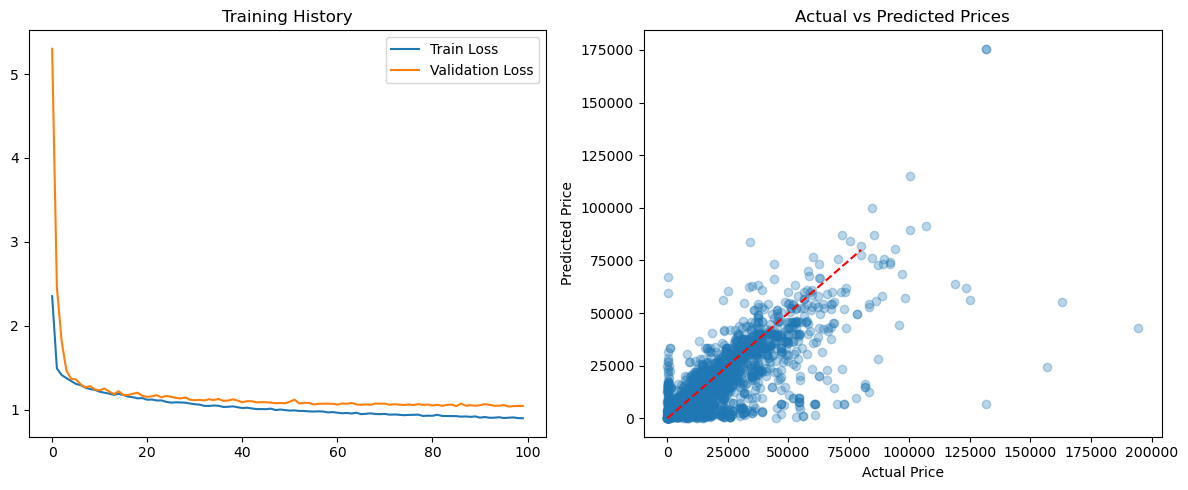

In [ ]:
# 训练过程可视化
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.legend()

# 预测结果可视化
plt.subplot(1, 2, 2)
plt.scatter(np.expm1(y_test), np.expm1(mlp.predict(X_test_processed)), alpha=0.3)
plt.plot([0, 80000], [0, 80000], '--r')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.tight_layout()
plt.show()